<!--
Copyright 2026 Yaroslav Mariukha
SPDX-License-Identifier: RPL-1.5

Unless explicitly acquired and licensed from Licensor under another license,
the contents of this file are subject to the Reciprocal Public License ("RPL")
Version 1.5, or subsequent versions as allowed by the RPL, and You may not copy
or use this file in either source code or executable form, except in compliance
with the terms and conditions of the RPL.

All software distributed under the RPL is provided strictly on an "AS IS"
basis, WITHOUT WARRANTY OF ANY KIND, EITHER EXPRESS OR IMPLIED, AND LICENSOR
HEREBY DISCLAIMS ALL SUCH WARRANTIES, INCLUDING WITHOUT LIMITATION, ANY
WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE, QUIET
ENJOYMENT, OR NON-INFRINGEMENT. See the RPL for specific language governing
rights and limitations under the RPL.
-->


# Video Frames and Avalon-ST Payloads

This tutorial introduces the simulator-independent representation of video frames and their Avalon-ST payload layout. It does not use Avalon-ST handshaking signals or require a simulator.

In [1]:
from cocotbext.avalon import AvalonFormat

from fpga_verification.video import (
    VideoFormat,
    FrameSize,
    ImageGenerator,
    VideoPayloadCodec,
    compare_frames,
)

## 1. AvalonFormat

[`AvalonFormat`](https://docs.altera.com/v/u/docs/655048/avalon-interface-specifications) describes the static arrangement of symbols inside the Avalon-ST `data` signal. It does not describe the complete Avalon-ST protocol: handshaking and packet signals such as `valid`, `ready`, `startofpacket`, `endofpacket`, and `empty` are handled by the bus helpers introduced in the next tutorial.

| Property | Meaning |
|---|---|
| `bits_per_symbol` | Width of one symbol in bits |
| `symbols_per_beat` | Number of symbols transferred in one beat |
| `first_symbol_in_high_order_bits` | Whether the first symbol occupies the most-significant rather than the least-significant bits |
| `payload_width` | Total width of the `data` signal in bits |

A **symbol** is the smallest independently ordered data item. A **beat** is everything transferred during one successful Avalon-ST clock transfer.

```text
payload_width = bits_per_symbol × symbols_per_beat
```

In [2]:
avalon_fmt = AvalonFormat(
    bits_per_symbol=8,
    symbols_per_beat=4,
    first_symbol_in_high_order_bits=False,
)

print(f"Payload width: {avalon_fmt.payload_width} bits")

Payload width: 32 bits


## 2. VideoFormat

`VideoFormat` specializes `AvalonFormat` for video samples. A sample is one color component of one pixel. For example, an RGB pixel contains three samples: R, G, and B.

| Property | Meaning |
|---|---|
| `bits_per_color` | Width of one color sample |
| `number_of_color_planes` | Number of samples in one pixel, for example 3 for RGB |
| `color_planes_are_in_parallel` | Whether all color planes are transferred in the same beat |
| `pixels_in_parallel` | Number of adjacent pixels transferred in parallel |

The generic Avalon properties are derived from the video properties:

```text
bits_per_symbol = bits_per_color

parallel color planes:
    symbols_per_beat = pixels_in_parallel × number_of_color_planes

serial color planes:
    symbols_per_beat = pixels_in_parallel
```

`VideoFormat` always places the first sample in the least-significant bits of the payload.

In [3]:
fmt = VideoFormat(
    bits_per_color=10,
    number_of_color_planes=3,
    color_planes_are_in_parallel=True,
    pixels_in_parallel=2,
)

print(f"Payload width: {fmt.payload_width} bits")
print(f"Sample mask: {fmt.sample_mask:#x}")

Payload width: 60 bits
Sample mask: 0x3ff


For the format above, one 60-bit beat carries two RGB pixels. Plane 0 of pixel 0 is the first symbol and occupies the least-significant 10 bits.

```text
MSB                                     LSB
+------+------+------+------+------+------+
| P1.2 | P1.1 | P1.0 | P0.2 | P0.1 | P0.0 |
+------+------+------+------+------+------+
 10 bit 10 bit 10 bit 10 bit  10 bit 10 bit
```

With serial color planes, one beat instead carries the same plane from `pixels_in_parallel` adjacent pixels.

In [4]:
serial_fmt = VideoFormat(
    bits_per_color=10,
    number_of_color_planes=3,
    color_planes_are_in_parallel=False,
    pixels_in_parallel=2,
)

print(f"Parallel-plane payload: {fmt.payload_width} bits")
print(f"Serial-plane payload: {serial_fmt.payload_width} bits")

Parallel-plane payload: 60 bits
Serial-plane payload: 20 bits


## 3. FrameSize

`FrameSize` stores the width and height of one frame. It is deliberately separate from `VideoFormat`: the interface layout may remain unchanged while the resolution changes between streams or frames.

A complete frame description is therefore the pair:

```text
VideoFormat + FrameSize
```

The canonical numpy shape is `(height, width)` for a single color plane and `(height, width, number_of_color_planes)` for multiple planes.

In [5]:
fmt = VideoFormat(
    bits_per_color=10,
    number_of_color_planes=3,
    color_planes_are_in_parallel=True,
    pixels_in_parallel=2,
)

size = FrameSize(width=5, height=3)

print(f"Frame shape: {fmt.frame_shape(size)}")
print(f"Row shape: {fmt.row_shape(size)}")
print(f"Samples in the frame: {fmt.frame_symbol_count(size)} = {size.height} * {size.width} * {fmt.number_of_color_planes}")
print(f"Pixels transferred in parallel: {fmt.pixels_in_parallel}")

Frame shape: (3, 5, 3)
Row shape: (5, 3)
Samples in the frame: 45 = 3 * 5 * 3
Pixels transferred in parallel: 2


## 4. ImageGenerator

`ImageGenerator` creates numpy frames that already have the shape, unsigned dtype, and sample range required by a `VideoFormat`. It is useful for generating deterministic stimulus without loading image files.

| Method | Generated pattern |
|---|---|
| `constant()` | One value in every sample |
| `horizontal_ramp()` | A left-to-right ramp repeated on every row and plane |
| `linspace()` | A ramp across all samples in the flattened frame |
| `random()` | Uniformly distributed random samples |

Passing a seed as `rng` makes random test stimulus reproducible. Generated values are checked against `bits_per_color`.

Shape: (3, 5, 3)
dtype: uint16
First random RGB pixel: [915, 484, 759]
Horizontal ramp, plane 0: [0, 255, 511, 767, 1023]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [9..1000].


Text(0.5, 1.0, 'random_frame')

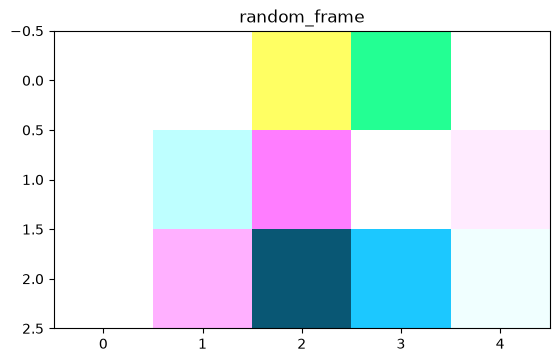

In [6]:
generator = ImageGenerator(fmt, rng=1)

black = generator.constant(size, value=0)
ramp = generator.horizontal_ramp(size)
random_frame = generator.random(size)

print(f"Shape: {random_frame.shape}")
print(f"dtype: {random_frame.dtype}")
print(f"First random RGB pixel: {random_frame[0, 0].tolist()}")
print(f"Horizontal ramp, plane 0: {ramp[0, :, 0].tolist()}")

from matplotlib import pyplot as plt

plt.imshow(random_frame);
plt.title('random_frame')

## 5. VideoPayloadCodec

`VideoPayloadCodec` converts between numpy frames, rows, individual samples, and packed Avalon-ST payload words. It is stateless and protocol-neutral: it does not create Intel VIP control, user, or video packets.

```text
numpy frame ↔ rows ↔ symbols ↔ packed payload beats
```

The codec requires both `fmt` and `size`. The format determines how samples are ordered and packed; the frame size determines the expected array shape and payload length.

In [7]:
codec = VideoPayloadCodec(fmt)
row = ramp[0]

row_symbols = codec.row_to_symbols(row, size)
row_beats = codec.pack_row(row, size)
decoded_row = codec.unpack_row(row_beats, size)

print(f"Pixels in the row: {size.width}")
print(f"Symbols in the padded row: {len(row_symbols)}")
print(f"Beats in the row: {len(row_beats)}")
print(f"Last beat symbols: {row_symbols[-fmt.samples_per_beat:]}")
print(f"Row round trip succeeded: {(decoded_row == row).all()}")

Pixels in the row: 5
Symbols in the padded row: 18
Beats in the row: 3
Last beat symbols: [1023, 1023, 1023, 0, 0, 0]
Row round trip succeeded: True


The example transfers two pixels per beat, but the row contains five pixels. The final beat therefore contains one real RGB pixel followed by one zero-valued padding pixel. `unpack_row()` checks that padding symbols are zero and removes them.

Frame-level packed conversion applies this padding independently to every row.

In [8]:
packed = codec.pack_frame(random_frame, size)
decoded = codec.unpack_frame(packed, size)

compare_frames(decoded, random_frame)
print(f"Packed frame beats: {len(packed)}")
print("Packed frame round trip succeeded")

Packed frame beats: 9
Packed frame round trip succeeded


For protocols that carry a continuous raster stream, use `frame_to_symbols()` instead. It returns exactly one symbol per color sample and does not add row padding. A later protocol or bus layer is responsible for handling a partial final beat.

In [9]:
symbols = codec.frame_to_symbols(random_frame, size)
decoded_from_symbols = codec.symbols_to_frame(symbols, size)

compare_frames(decoded_from_symbols, random_frame)
print(f"Frame symbols without row padding: {len(symbols)}")
print("Symbol stream round trip succeeded")

Frame symbols without row padding: 45
Symbol stream round trip succeeded


### Rows and validation

`validate_frame()` checks shape, integer sample type, and sample range, then normalizes the storage dtype. `frame_to_rows()` returns independent row copies and `rows_to_frame()` validates and stacks them. These adapters are useful for line-buffer models that process one row at a time.

In [10]:
validated = codec.validate_frame(random_frame, size)
rows = codec.frame_to_rows(validated, size)
decoded_from_rows = codec.rows_to_frame(rows, size)

compare_frames(decoded_from_rows, random_frame)
print(f"Rows: {len(rows)}, row shape: {rows[0].shape}")

Rows: 3, row shape: (5, 3)


## 6. Comparing frames

`compare_frames(actual, expected, tolerance=0)` checks shapes and compares every sample. It returns `True` on success and raises `AssertionError` with the first mismatch coordinate, values, difference, and total mismatch count on failure. A nonzero tolerance is useful for fixed-point image pipelines with bounded rounding error.

In [11]:
slightly_different = random_frame.copy()
slightly_different[0, 0, 0] += 1

compare_frames(slightly_different, random_frame, tolerance=1)

try:
    compare_frames(slightly_different, random_frame)
except AssertionError as error:
    print(error)

frame mismatch: 1 mismatches, first at y=0, x=0, plane=0: got 916, expected 915, diff=1, tolerance=0


## Next step

`VideoPayloadCodec` stops at protocol-neutral samples and payload beats. Continue with `05_intel_vip_packets_and_agent.ipynb` to wrap a continuous video symbol stream in Intel control, user, and video packets.